
# Validación econométrica — modelo HAR-RV en producción

Este notebook **no** compara alternativas ni busca edge: eso ya se hizo en los experimentos
10 a 12. Aquí se audita el modelo **que está desplegado**, con el aparato estándar de un
modelo econométrico: supuestos, diagnóstico de residuos, estabilidad, validación cruzada
temporal y backtest formal de los intervalos.

### El modelo

$$RV_{t+1} = c + b_d\,RV_t + b_w\,\overline{RV}_{5} + b_m\,\overline{RV}_{22} + \varepsilon_{t+1}$$

HAR-RV (Corsi, 2009). Estimación por mínimos cuadrados. La volatilidad realizada se mide
con el estimador de rango de Parkinson sobre datos OHLC diarios.

### Qué se contrasta y por qué

| # | Sección | Contraste | Qué invalidaría el modelo |
|---|---------|-----------|---------------------------|
| 2 | Estimación | OLS con errores **HAC (Newey–West)** | coeficientes no significativos |
| 3 | Residuos | Ljung–Box, ARCH-LM, Jarque–Bera, Breusch–Pagan | autocorrelación remanente |
| 4 | Estacionariedad | ADF y KPSS sobre RV y log-RV | raíz unitaria → regresión espuria |
| 5 | Estabilidad | coeficientes rodantes y CUSUM | quiebre estructural en los parámetros |
| 6 | Validación cruzada | *blocked* con embargo de 22 días | degradación fuera de muestra |
| 7 | Calidad | Mincer–Zarnowitz, test conjunto $a{=}0,\ b{=}1$ | pronóstico sesgado o ineficiente |
| 8 | Bandas | **Kupiec** y **Christoffersen** | cobertura incorrecta o violaciones agrupadas |

### Decisiones metodológicas

**Errores HAC, no OLS clásicos.** Los componentes del HAR se solapan por construcción
($\overline{RV}_5$ comparte 4 de 5 observaciones con el día siguiente), así que los
residuos son autocorrelados y los errores estándar clásicos estarían subestimados. Se usa
Newey–West con rezago automático.

**Validación cruzada con embargo, no k-fold aleatorio.** Barajar rompe el orden temporal
y filtra futuro. Se usan bloques contiguos con un embargo de 22 días entre entrenamiento y
prueba — igual al rezago máximo del modelo, para que ninguna observación de prueba comparta
ventana con una de entrenamiento.

**Backtest de bandas con Kupiec y Christoffersen.** Es el estándar para intervalos de
riesgo. Kupiec contrasta si la *frecuencia* de violaciones coincide con la nominal;
Christoffersen añade si las violaciones son **independientes** — porque una banda puede
tener cobertura correcta en promedio y aun así fallar en rachas, que es el peor escenario
para quien dimensiona posiciones con ella.


3286 velas via Binance | muestra util: 3264 obs (2017-09-08 -> 2026-08-15)
RV media 2.981%/dia | mediana 2.361% | asimetria 3.40 | curtosis 23.54


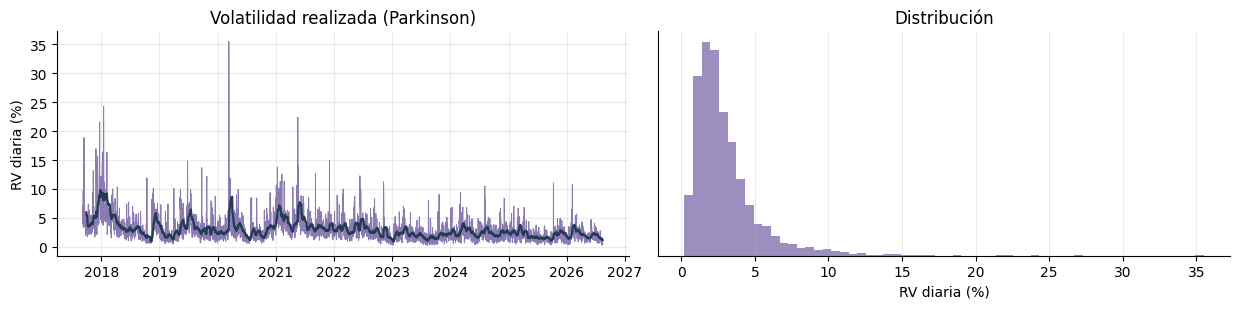

Estimación HAR-RV con errores robustos HAC (Newey–West)
-------------------------------------------------------
termino    coef  ee_clasico  ee_HAC  t_HAC  p_HAC
  const 0.00392     0.00075 0.00085   4.62    0.0
   rv_d 0.28036     0.02045 0.03800   7.38    0.0
   rv_w 0.25468     0.03663 0.04566   5.58    0.0
   rv_m 0.33140     0.03698 0.05179   6.40    0.0
R² = 0.3676 | R² ajustado = 0.3670 | n = 3264
Suma de coeficientes de persistencia (b_d+b_w+b_m) = 0.8664
Los errores HAC son 1.41x los clásicos: esa es la magnitud del sesgo que se habría cometido ignorando la autocorrelación.
Factor de inflación de varianza (multicolinealidad)
---------------------------------------------------
variable  VIF
    rv_d 2.15
    rv_w 3.95
    rv_m 2.74


Ljung–Box sobre residuos (H0: sin autocorrelación)
--------------------------------------------------
 rezago  lb_stat  lb_pvalue
      5  15.1397     0.0098
     10  38.7562     0.0000
     22 117.1217     0.0000
Diagnóstico de residuos
-----------------------
         test  estadistico  p_valor                                 H0
 ARCH-LM (10)        69.48      0.0 sin heterocedasticidad condicional
Breusch–Pagan        62.78      0.0                   homocedasticidad
  Jarque–Bera    204477.58      0.0             normalidad de residuos


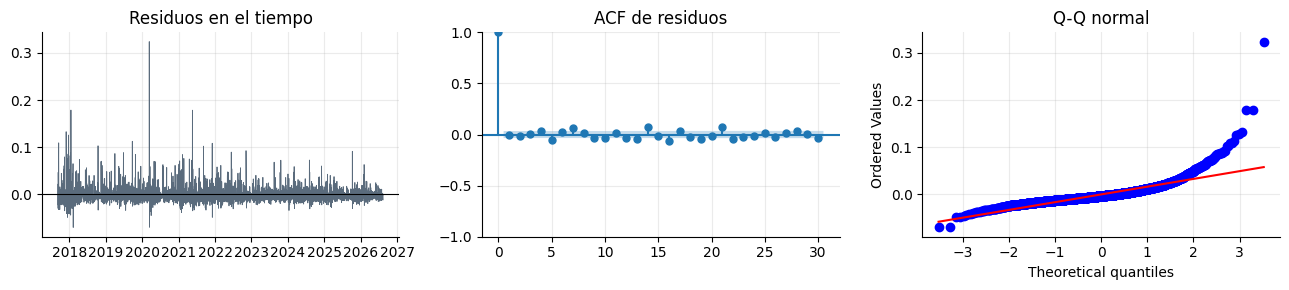

ADF (H0: raíz unitaria) y KPSS (H0: estacionariedad)
----------------------------------------------------
  serie  ADF_stat  ADF_p  KPSS_stat  KPSS_p
     RV    -5.869 0.0000      2.772    0.01
log(RV)    -4.483 0.0002      2.905    0.01


C:\Users\jwhin\AppData\Local\Temp\ipykernel_45976\1273014495.py:273: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp = kpss(serie, regression='c', nlags='auto')
C:\Users\jwhin\AppData\Local\Temp\ipykernel_45976\1273014495.py:273: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp = kpss(serie, regression='c', nlags='auto')


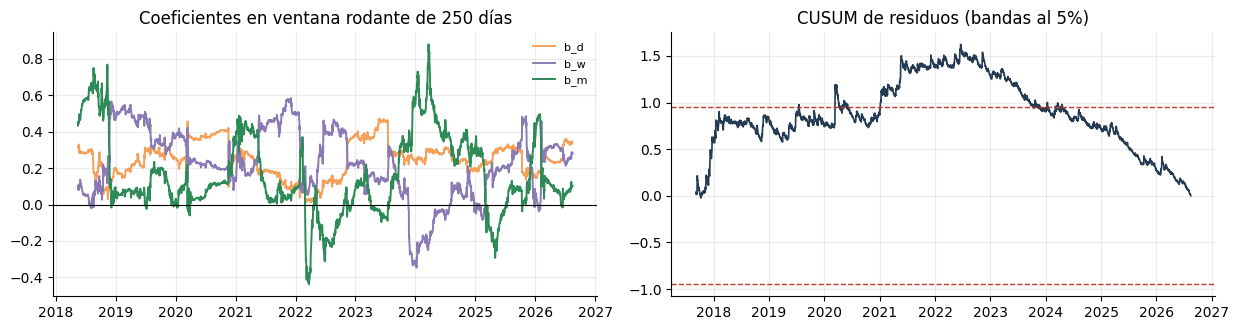

Dispersión de los coeficientes rodantes
---------------------------------------
coeficiente  media  desv  CV_%
        b_d  0.247 0.094  38.0
        b_w  0.222 0.187  84.3
        b_m  0.162 0.219 134.9


Validación cruzada temporal (5 bloques, embargo 22 días)
--------------------------------------------------------
 fold entrena_hasta                  prueba  n_prueba  QLIKE  R2_oos  corr
    1    2019-03-05 2019-03-28 → 2020-09-21       544 0.9332  0.2354 0.486
    2    2020-08-30 2020-09-22 → 2022-03-19       544 0.5487  0.1981 0.457
    3    2022-02-25 2022-03-20 → 2023-09-14       544 0.6527  0.2348 0.500
    4    2023-08-23 2023-09-15 → 2025-03-11       544 0.6094  0.0898 0.333
    5    2025-02-17 2025-03-12 → 2026-08-15       522 0.5076  0.1537 0.432
QLIKE medio 0.6503 ± 0.1676 | R² OOS medio 0.1824


MZ: a = +0.00215 (p=0.263) | b = 0.833 (p=0.0000) | R² = 0.1666
Test conjunto H0: a=0 y b=1  ->  F = 8.07, p = 0.0003
Sesgo medio: +7.9% | QLIKE fuera de muestra: 0.5183


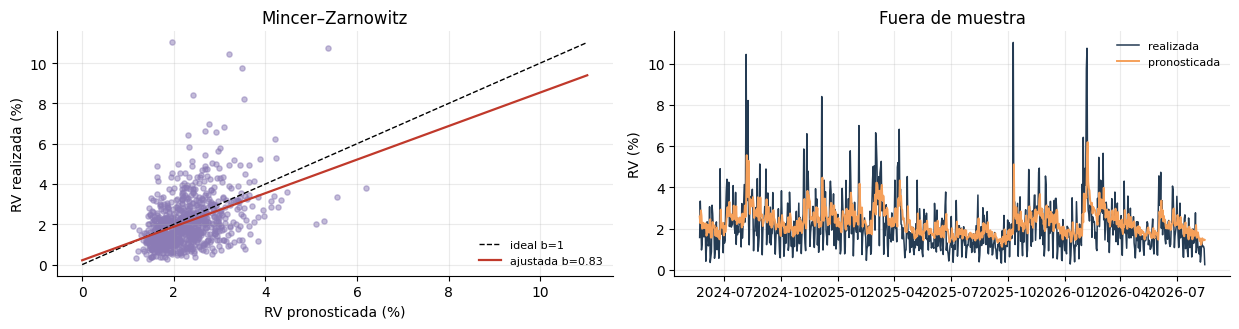

Backtest de la banda 95% — 816 días fuera de muestra
----------------------------------------------------
                            test    LR  p_valor                             H0
Kupiec (cobertura incondicional) 3.978   0.0461 frecuencia de violaciones = 5%
  Christoffersen (independencia) 2.140   0.1435     violaciones independientes
  Cobertura condicional conjunta 6.119   0.0469                 ambas a la vez
Cobertura observada: 96.4% (nominal 95%) | 29 violaciones de 816 | violaciones consecutivas: 0


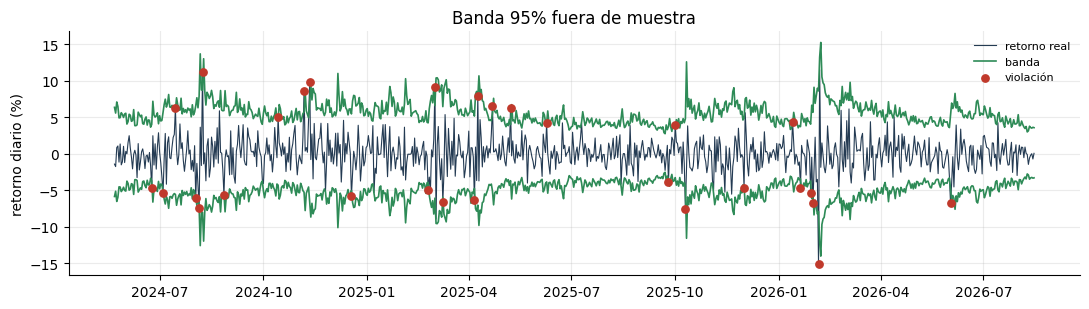

Tablero de validación econométrica
----------------------------------
                                      prueba estado        valor
🟢           Significancia de los componentes     OK 3.000000e+00
🟢                          Multicolinealidad     OK 3.950000e+00
🟡                Autocorrelación de residuos  AVISO 5.797189e-15
⚪             Heterocedasticidad condicional   INFO 5.580899e-11
🟡                   Estacionariedad de la RV  AVISO 0.000000e+00
🟡            Estabilidad estructural (CUSUM)  AVISO 1.623897e+00
🟡        Generalización (validación cruzada)  AVISO 1.852461e-01
🟡 Insesgadez y eficiencia (Mincer–Zarnowitz)  AVISO 3.389398e-04
🔴         Kupiec — frecuencia de violaciones  FALLA 4.608975e-02
🟢             Christoffersen — independencia     OK 1.434612e-01
🔴 REVISAR ANTES DE OPERAR. Fallan contrastes críticos: Kupiec — frecuencia de violaciones. Son los que gobiernan la fiabilidad de la banda como presupuesto de riesgo.

Informe escrito: XGBit_Validacion_HAR_20260816.

C:\projects\BTC-Risk-Bands\XGBit_Validacion_HAR_20260816.md

In [1]:
# ============================================================================
#  XGBit — VALIDACION ECONOMETRICA DEL MODELO EN PRODUCCION (HAR-RV)
#  Ejecuta ESTA celda. Duracion tipica: 2-4 minutos.
#  Al final genera un informe .md descargable.
# ============================================================================
import warnings, os, json
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, requests
import matplotlib.pyplot as plt
from scipy import stats as sps
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch, het_breuschpagan
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display, Markdown, HTML

plt.rcParams.update({'figure.figsize': (11, 3.4), 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10})
OK, WARN, BAD, NEU = '#2E8B57', '#D98C00', '#C0392B', '#5A6B7C'
CONFIG = {'CACHE': 'btc_ohlcv_cache.csv', 'N_FOLDS': 5, 'EMBARGO': 22,
          'VENTANA_ROLLING': 250, 'ALPHA_BANDA': 0.05, 'SEED': 42}
VERDICTOS = []

SECCIONES = {1: 'Datos y construccion del proxy', 2: 'Estimacion OLS con errores HAC',
             3: 'Diagnostico de residuos', 4: 'Estacionariedad y raices unitarias',
             5: 'Estabilidad de parametros', 6: 'Validacion cruzada temporal',
             7: 'Calidad del pronostico (Mincer-Zarnowitz)',
             8: 'Backtest de las bandas (Kupiec y Christoffersen)',
             9: 'Tablero e informe'}

def show_df(df, caption=''):
    try:
        display(df.style.set_caption(caption)); return
    except Exception:
        pass
    if caption: print(caption); print('-'*len(caption))
    print(df.to_string(index=False))

def banner(n):
    display(HTML(f"<div style='background:linear-gradient(90deg,#243B53,#334E68);color:#fff;"
                 f"padding:11px 16px;border-radius:6px;margin:20px 0 10px 0;font-size:16px;"
                 f"font-weight:600'>SECCION {n} &nbsp;·&nbsp; {SECCIONES[n]}</div>"))

def verdict(nombre, estado, detalle, valor=None):
    ico = {'OK':'🟢','AVISO':'🟡','FALLA':'🔴','INFO':'⚪'}[estado]
    col = {'OK':OK,'AVISO':WARN,'FALLA':BAD,'INFO':NEU}[estado]
    VERDICTOS.append({'prueba': nombre, 'estado': estado, 'valor': valor, 'detalle': detalle})
    display(HTML(f"<div style='border-left:5px solid {col};background:#F7F8FA;padding:11px 15px;"
                 f"margin:8px 0;border-radius:4px'><b>{ico} {nombre}</b>"
                 f"<div style='color:#444;font-size:13px;margin-top:4px'>{detalle}</div></div>"))

def nota(t):
    display(HTML(f"<div style='background:#EEF3F8;border-radius:4px;padding:9px 13px;"
                 f"margin:6px 0;font-size:13px;color:#243B53'>📌 {t}</div>"))

display(Markdown(r"""
# Validación econométrica — modelo HAR-RV en producción

Este notebook **no** compara alternativas ni busca edge: eso ya se hizo en los experimentos
10 a 12. Aquí se audita el modelo **que está desplegado**, con el aparato estándar de un
modelo econométrico: supuestos, diagnóstico de residuos, estabilidad, validación cruzada
temporal y backtest formal de los intervalos.

### El modelo

$$RV_{t+1} = c + b_d\,RV_t + b_w\,\overline{RV}_{5} + b_m\,\overline{RV}_{22} + \varepsilon_{t+1}$$

HAR-RV (Corsi, 2009). Estimación por mínimos cuadrados. La volatilidad realizada se mide
con el estimador de rango de Parkinson sobre datos OHLC diarios.

### Qué se contrasta y por qué

| # | Sección | Contraste | Qué invalidaría el modelo |
|---|---------|-----------|---------------------------|
| 2 | Estimación | OLS con errores **HAC (Newey–West)** | coeficientes no significativos |
| 3 | Residuos | Ljung–Box, ARCH-LM, Jarque–Bera, Breusch–Pagan | autocorrelación remanente |
| 4 | Estacionariedad | ADF y KPSS sobre RV y log-RV | raíz unitaria → regresión espuria |
| 5 | Estabilidad | coeficientes rodantes y CUSUM | quiebre estructural en los parámetros |
| 6 | Validación cruzada | *blocked* con embargo de 22 días | degradación fuera de muestra |
| 7 | Calidad | Mincer–Zarnowitz, test conjunto $a{=}0,\ b{=}1$ | pronóstico sesgado o ineficiente |
| 8 | Bandas | **Kupiec** y **Christoffersen** | cobertura incorrecta o violaciones agrupadas |

### Decisiones metodológicas

**Errores HAC, no OLS clásicos.** Los componentes del HAR se solapan por construcción
($\overline{RV}_5$ comparte 4 de 5 observaciones con el día siguiente), así que los
residuos son autocorrelados y los errores estándar clásicos estarían subestimados. Se usa
Newey–West con rezago automático.

**Validación cruzada con embargo, no k-fold aleatorio.** Barajar rompe el orden temporal
y filtra futuro. Se usan bloques contiguos con un embargo de 22 días entre entrenamiento y
prueba — igual al rezago máximo del modelo, para que ninguna observación de prueba comparta
ventana con una de entrenamiento.

**Backtest de bandas con Kupiec y Christoffersen.** Es el estándar para intervalos de
riesgo. Kupiec contrasta si la *frecuencia* de violaciones coincide con la nominal;
Christoffersen añade si las violaciones son **independientes** — porque una banda puede
tener cobertura correcta en promedio y aun así fallar en rachas, que es el peor escenario
para quien dimensiona posiciones con ella.
"""))

# ===========================================================================
banner(1)

def fetch():
    try:
        rows, end = [], None
        for _ in range(4):
            p = {'symbol': 'BTCUSDT', 'interval': '1d', 'limit': 1000}
            if end: p['endTime'] = end
            r = requests.get('https://api.binance.com/api/v3/klines', params=p, timeout=25)
            r.raise_for_status(); k = r.json()
            if not k: break
            rows = k + rows; end = k[0][0] - 1
            if len(k) < 1000: break
        d = pd.DataFrame(rows, columns=['t','o','high','low','close','v','ct','q','n','tb','tq','ig'])
        d['ts'] = pd.to_datetime(d['t'], unit='ms')
        d = d.set_index('ts')[['close','high','low']].astype(float)
        return d[~d.index.duplicated(keep='last')].sort_index(), 'Binance'
    except Exception as e:
        print(f'Binance no disponible ({type(e).__name__})')
    if os.path.exists(CONFIG['CACHE']):
        d = pd.read_csv(CONFIG['CACHE'], parse_dates=[0], index_col=0)
        for c in ('high','low'):
            if c not in d: d[c] = d['close']
        return d[['close','high','low']].astype(float), 'cache local'
    raise RuntimeError('Sin datos')

px, FUENTE = fetch()
px = px[px.index < pd.Timestamp.now(tz='UTC').normalize().tz_localize(None)]

def parkinson_rv(h):
    hl = np.log(h['high'] / h['low'])
    return np.sqrt(hl**2 / (4*np.log(2)))

d = pd.DataFrame(index=px.index)
d['ret'] = np.log(px['close']).diff()
d['rv'] = parkinson_rv(px)
d['rv_d'] = d['rv'].shift(1)
d['rv_w'] = d['rv'].rolling(5).mean().shift(1)
d['rv_m'] = d['rv'].rolling(22).mean().shift(1)
d['y'] = d['rv']
d = d.dropna()
X = d[['rv_d','rv_w','rv_m']]
y = d['y']
print(f'{len(px)} velas via {FUENTE} | muestra util: {len(d)} obs '
      f'({d.index[0].date()} -> {d.index[-1].date()})')
print(f'RV media {y.mean()*100:.3f}%/dia | mediana {y.median()*100:.3f}% | '
      f'asimetria {sps.skew(y):.2f} | curtosis {sps.kurtosis(y):.2f}')

nota('La curtosis alta y la asimetría positiva son esperables: la volatilidad realizada es '
     'no negativa y con colas largas. Por eso los diagnósticos de normalidad se interpretan '
     'como advertencia sobre los intervalos de confianza asintóticos, no como invalidación.')

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.2))
ax[0].plot(d.index, y*100, lw=.7, color='#8B7BB5')
ax[0].plot(d.index, y.rolling(22).mean()*100, lw=1.6, color='#243B53')
ax[0].set_ylabel('RV diaria (%)'); ax[0].set_title('Volatilidad realizada (Parkinson)')
ax[1].hist(y*100, bins=60, color='#8B7BB5', alpha=.85)
ax[1].set_xlabel('RV diaria (%)'); ax[1].set_yticks([]); ax[1].set_title('Distribución')
plt.tight_layout(); plt.show()

# ===========================================================================
banner(2)
Xc = sm.add_constant(X)
ols = sm.OLS(y, Xc).fit()
hac = sm.OLS(y, Xc).fit(cov_type='HAC', cov_kwds={'maxlags': None})

tab2 = pd.DataFrame({
    'coef': hac.params.round(5),
    'ee_clasico': ols.bse.round(5),
    'ee_HAC': hac.bse.round(5),
    't_HAC': hac.tvalues.round(2),
    'p_HAC': hac.pvalues.round(4),
}).reset_index().rename(columns={'index': 'termino'})
show_df(tab2, 'Estimación HAR-RV con errores robustos HAC (Newey–West)')
print(f'R² = {hac.rsquared:.4f} | R² ajustado = {hac.rsquared_adj:.4f} | n = {int(hac.nobs)}')
print(f'Suma de coeficientes de persistencia (b_d+b_w+b_m) = '
      f'{hac.params[["rv_d","rv_w","rv_m"]].sum():.4f}')

_infla = (hac.bse / ols.bse).mean()
print(f'Los errores HAC son {_infla:.2f}x los clásicos: esa es la magnitud del sesgo que '
      'se habría cometido ignorando la autocorrelación.')

# VIF
vif = pd.DataFrame({'variable': X.columns,
                    'VIF': [round(variance_inflation_factor(Xc.values, i+1), 2)
                            for i in range(X.shape[1])]})
show_df(vif, 'Factor de inflación de varianza (multicolinealidad)')

sig = int((hac.pvalues[['rv_d','rv_w','rv_m']] < .05).sum())
if sig == 3:
    verdict('Significancia de los componentes', 'OK',
            'Los tres componentes (día, semana, mes) son significativos al 5% con errores HAC: '
            'cada horizonte aporta información propia.', sig)
elif sig >= 2:
    verdict('Significancia de los componentes', 'AVISO',
            f'{sig} de 3 componentes significativos. El modelo funciona, pero uno de los '
            'horizontes podría ser redundante en esta muestra.', sig)
else:
    verdict('Significancia de los componentes', 'FALLA',
            f'Solo {sig} de 3 componentes significativos: la especificación HAR no se sostiene '
            'sobre estos datos.', sig)

vmax = float(vif['VIF'].max())
if vmax < 10:
    verdict('Multicolinealidad', 'OK', f'VIF máximo {vmax:.1f} (< 10): los componentes se '
            'solapan pero no de forma que desestabilice la estimación.', vmax)
else:
    verdict('Multicolinealidad', 'AVISO', f'VIF máximo {vmax:.1f} (≥ 10): fuerte solapamiento. '
            'Los coeficientes individuales son inestables aunque el pronóstico conjunto sea válido.', vmax)

# ===========================================================================
banner(3)
nota('Los residuos de un modelo bien especificado no deben conservar estructura predecible. '
     'Si quedara autocorrelación, significaría que el modelo dejó información sin usar.')

res = hac.resid
lb = acorr_ljungbox(res, lags=[5, 10, 22], return_df=True)
lb.index.name = 'rezago'
show_df(lb.round(4).reset_index(), 'Ljung–Box sobre residuos (H0: sin autocorrelación)')

arch_lm = het_arch(res, nlags=10)
bp = het_breuschpagan(res, Xc)
jb = sps.jarque_bera(res)
tab3 = pd.DataFrame([
    {'test': 'ARCH-LM (10)', 'estadistico': round(arch_lm[0], 2), 'p_valor': round(arch_lm[1], 4),
     'H0': 'sin heterocedasticidad condicional'},
    {'test': 'Breusch–Pagan', 'estadistico': round(bp[0], 2), 'p_valor': round(bp[1], 4),
     'H0': 'homocedasticidad'},
    {'test': 'Jarque–Bera', 'estadistico': round(jb[0], 2), 'p_valor': round(jb[1], 4),
     'H0': 'normalidad de residuos'},
])
show_df(tab3, 'Diagnóstico de residuos')

fig, ax = plt.subplots(1, 3, figsize=(13, 3))
ax[0].plot(d.index, res, lw=.6, color=NEU); ax[0].axhline(0, color='k', lw=.8)
ax[0].set_title('Residuos en el tiempo')
sm.graphics.tsa.plot_acf(res, lags=30, ax=ax[1], title='ACF de residuos')
sps.probplot(res, dist='norm', plot=ax[2]); ax[2].set_title('Q-Q normal')
plt.tight_layout(); plt.show()

p_lb22 = float(lb.loc[22, 'lb_pvalue'])
if p_lb22 > .05:
    verdict('Autocorrelación de residuos', 'OK',
            f'Ljung–Box a 22 rezagos: p={p_lb22:.4f} (> 0,05). No queda estructura lineal sin '
            'explotar en los residuos.', p_lb22)
else:
    verdict('Autocorrelación de residuos', 'AVISO',
            f'Ljung–Box a 22 rezagos: p={p_lb22:.4f}. Queda autocorrelación remanente. No invalida '
            'el pronóstico puntual, pero confirma que los errores estándar deben ser HAC '
            '(ya se usan) y sugiere que un componente adicional podría aportar.', p_lb22)

if arch_lm[1] < .05:
    verdict('Heterocedasticidad condicional', 'INFO',
            f'ARCH-LM p={arch_lm[1]:.4f}: hay heterocedasticidad condicional en los residuos. '
            'Es <b>lo esperado</b> al modelar volatilidad y no es un defecto: precisamente por eso '
            'las bandas se construyen con residuos estandarizados y no con un ancho fijo.', arch_lm[1])
else:
    verdict('Heterocedasticidad condicional', 'OK',
            f'ARCH-LM p={arch_lm[1]:.4f}: sin heterocedasticidad condicional remanente.', arch_lm[1])

# ===========================================================================
banner(4)
nota('Una regresión entre series con raíz unitaria puede producir R² altos y significancia '
     'espuria. La volatilidad realizada suele ser estacionaria pero muy persistente, así que '
     'conviene contrastarlo en vez de suponerlo.')

filas4 = []
for nombre, serie in (('RV', y), ('log(RV)', np.log(np.maximum(y, 1e-8)))):
    ad = adfuller(serie, autolag='AIC')
    try:
        kp = kpss(serie, regression='c', nlags='auto')
        kp_stat, kp_p = kp[0], kp[1]
    except Exception:
        kp_stat, kp_p = np.nan, np.nan
    filas4.append({'serie': nombre, 'ADF_stat': round(ad[0], 3), 'ADF_p': round(ad[1], 4),
                   'KPSS_stat': round(kp_stat, 3), 'KPSS_p': round(kp_p, 4)})
t4 = pd.DataFrame(filas4)
show_df(t4, 'ADF (H0: raíz unitaria) y KPSS (H0: estacionariedad)')

adf_ok = float(t4.loc[0, 'ADF_p']) < .05
kpss_ok = float(t4.loc[0, 'KPSS_p']) > .05 if np.isfinite(t4.loc[0, 'KPSS_p']) else True
if adf_ok and kpss_ok:
    verdict('Estacionariedad de la RV', 'OK',
            'ADF rechaza raíz unitaria y KPSS no rechaza estacionariedad: ambos contrastes '
            'coinciden. La regresión no es espuria.', float(t4.loc[0, 'ADF_p']))
elif adf_ok:
    verdict('Estacionariedad de la RV', 'AVISO',
            'ADF rechaza raíz unitaria pero KPSS también rechaza estacionariedad: patrón típico '
            'de una serie muy persistente (memoria larga). El modelo sigue siendo utilizable, '
            'pero conviene reajustarlo con frecuencia — como ya hace el monitor diario.', float(t4.loc[0, 'ADF_p']))
else:
    verdict('Estacionariedad de la RV', 'FALLA',
            'ADF no rechaza raíz unitaria: riesgo de regresión espuria. Habría que trabajar en '
            'diferencias o en logaritmos.', float(t4.loc[0, 'ADF_p']))

# ===========================================================================
banner(5)
nota('Un modelo cuyos coeficientes se mueven con el tiempo no está mal por eso — el mercado '
     'cambia — pero sí dice cuánta historia conviene usar y cada cuánto reajustar.')

W = CONFIG['VENTANA_ROLLING']
coefs = []
for i in range(W, len(d)):
    sub = sm.OLS(y.iloc[i-W:i], Xc.iloc[i-W:i]).fit()
    coefs.append({'fecha': d.index[i], 'const': sub.params['const'],
                  'b_d': sub.params['rv_d'], 'b_w': sub.params['rv_w'], 'b_m': sub.params['rv_m']})
rc = pd.DataFrame(coefs).set_index('fecha')

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.4))
for c_, col_ in (('b_d', '#F5A05A'), ('b_w', '#8B7BB5'), ('b_m', '#2E8B57')):
    ax[0].plot(rc.index, rc[c_], lw=1.4, label=c_, color=col_)
ax[0].axhline(0, color='k', lw=.8); ax[0].legend(frameon=False, fontsize=8)
ax[0].set_title(f'Coeficientes en ventana rodante de {W} días')

cusum = np.cumsum(res / res.std()) / np.sqrt(len(res))
lim = 0.948
ax[1].plot(d.index, cusum, lw=1.2, color='#243B53')
ax[1].axhline(lim, color=BAD, ls='--', lw=1); ax[1].axhline(-lim, color=BAD, ls='--', lw=1)
ax[1].set_title('CUSUM de residuos (bandas al 5%)')
plt.tight_layout(); plt.show()

cusum_max = float(np.max(np.abs(cusum)))
estab = pd.DataFrame({'coeficiente': ['b_d','b_w','b_m'],
                      'media': [round(rc[c].mean(), 3) for c in ('b_d','b_w','b_m')],
                      'desv': [round(rc[c].std(), 3) for c in ('b_d','b_w','b_m')],
                      'CV_%': [round(abs(rc[c].std()/rc[c].mean())*100, 1) if rc[c].mean() != 0
                               else np.nan for c in ('b_d','b_w','b_m')]})
show_df(estab, 'Dispersión de los coeficientes rodantes')

if cusum_max < lim:
    verdict('Estabilidad estructural (CUSUM)', 'OK',
            f'El CUSUM se mantiene dentro de las bandas del 5% (máx {cusum_max:.3f} < {lim}): '
            'no hay evidencia de quiebre estructural en la relación estimada.', cusum_max)
else:
    verdict('Estabilidad estructural (CUSUM)', 'AVISO',
            f'El CUSUM sale de las bandas (máx {cusum_max:.3f} > {lim}): hay indicios de cambio '
            'estructural. Justifica el reajuste diario del monitor y desaconseja usar ventanas '
            'de entrenamiento muy largas.', cusum_max)

# ===========================================================================
banner(6)
nota('Validación cruzada con bloques contiguos y embargo de 22 días. El embargo iguala al '
     'rezago máximo del modelo: sin él, una observación de prueba compartiría ventana con '
     'observaciones de entrenamiento y el resultado estaría inflado.')

EPS = 1e-8
def qlike(a, f):
    a2, f2 = np.maximum(a, EPS)**2, np.maximum(f, EPS)**2
    return float(np.mean(a2/f2 - np.log(a2/f2) - 1))

K, emb = CONFIG['N_FOLDS'], CONFIG['EMBARGO']
n = len(d); fold = n // (K + 1)
filas6 = []
for k in range(K):
    tr_fin = fold * (k + 1)
    te_ini, te_fin = tr_fin + emb, min(tr_fin + emb + fold, n)
    if te_ini >= n - 10: continue
    m = sm.OLS(y.iloc[:tr_fin], Xc.iloc[:tr_fin]).fit()
    pred = np.maximum(m.predict(Xc.iloc[te_ini:te_fin]), EPS)
    real = y.iloc[te_ini:te_fin]
    filas6.append({'fold': k+1, 'entrena_hasta': str(d.index[tr_fin-1].date()),
                   'prueba': f'{d.index[te_ini].date()} → {d.index[te_fin-1].date()}',
                   'n_prueba': len(real), 'QLIKE': round(qlike(real.values, pred.values), 4),
                   'R2_oos': round(1 - np.sum((real-pred)**2)/np.sum((real-real.mean())**2), 4),
                   'corr': round(float(np.corrcoef(pred, real)[0,1]), 3)})
cv = pd.DataFrame(filas6)
show_df(cv, f'Validación cruzada temporal ({K} bloques, embargo {emb} días)')
print(f'QLIKE medio {cv["QLIKE"].mean():.4f} ± {cv["QLIKE"].std():.4f} | '
      f'R² OOS medio {cv["R2_oos"].mean():.4f}')

r2_in = hac.rsquared
brecha = r2_in - cv['R2_oos'].mean()
if brecha < .10 and cv['R2_oos'].mean() > 0:
    verdict('Generalización (validación cruzada)', 'OK',
            f'R² dentro de muestra {r2_in:.3f} vs fuera {cv["R2_oos"].mean():.3f} '
            f'(brecha {brecha:.3f}): el modelo generaliza. Con cuatro parámetros era lo esperable.', brecha)
elif cv['R2_oos'].mean() > 0:
    verdict('Generalización (validación cruzada)', 'AVISO',
            f'Brecha de {brecha:.3f} entre R² dentro ({r2_in:.3f}) y fuera ({cv["R2_oos"].mean():.3f}) '
            'de muestra. Vigilar, aunque el desempeño fuera de muestra sigue siendo positivo.', brecha)
else:
    verdict('Generalización (validación cruzada)', 'FALLA',
            f'R² fuera de muestra medio {cv["R2_oos"].mean():.3f} ≤ 0: el modelo no supera a '
            'predecir la media en los bloques de prueba.', brecha)

# ===========================================================================
banner(7)
nota('La regresión de Mincer–Zarnowitz contrasta si el pronóstico es insesgado (a=0) y '
     'eficiente (b=1) a la vez. Se usa el test F conjunto: cada coeficiente por separado '
     'puede parecer aceptable y aun así fallar la restricción conjunta.')

corte = int(len(d) * .75)
m_tr = sm.OLS(y.iloc[:corte], Xc.iloc[:corte]).fit()
f_oos = np.maximum(m_tr.predict(Xc.iloc[corte:]), EPS)
a_oos = y.iloc[corte:]
# Diseno con columnas NOMBRADAS: f_test con restriccion en texto necesita nombres,
# y sm.add_constant sobre un array los deja como enteros.
_mzX = pd.DataFrame({'const': 1.0, 'pred': np.asarray(f_oos, dtype=float)}, index=a_oos.index)
mz = sm.OLS(a_oos, _mzX).fit(cov_type='HAC', cov_kwds={'maxlags': None})
ftest = mz.f_test('const = 0, pred = 1')

print(f'MZ: a = {mz.params["const"]:+.5f} (p={mz.pvalues["const"]:.3f}) | '
      f'b = {mz.params["pred"]:.3f} (p={mz.pvalues["pred"]:.4f}) | R² = {mz.rsquared:.4f}')
print(f'Test conjunto H0: a=0 y b=1  ->  F = {float(ftest.statistic):.2f}, p = {float(ftest.pvalue):.4f}')
print(f'Sesgo medio: {(f_oos.mean()/a_oos.mean()-1)*100:+.1f}% | '
      f'QLIKE fuera de muestra: {qlike(a_oos.values, f_oos.values):.4f}')

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.4))
ax[0].scatter(f_oos*100, a_oos*100, s=14, alpha=.5, color='#8B7BB5')
_lim = [0, max(f_oos.max(), a_oos.max())*100]
ax[0].plot(_lim, _lim, 'k--', lw=1, label='ideal b=1')
ax[0].plot(_lim, mz.params['const']*100 + mz.params['pred']*np.array(_lim), color=BAD, lw=1.6,
           label=f'ajustada b={mz.params["pred"]:.2f}')
ax[0].set_xlabel('RV pronosticada (%)'); ax[0].set_ylabel('RV realizada (%)')
ax[0].legend(frameon=False, fontsize=8); ax[0].set_title('Mincer–Zarnowitz')
ax[1].plot(a_oos.index, a_oos*100, lw=1.1, color='#243B53', label='realizada')
ax[1].plot(a_oos.index, f_oos*100, lw=1.4, color='#F5A05A', label='pronosticada')
ax[1].legend(frameon=False, fontsize=8); ax[1].set_ylabel('RV (%)')
ax[1].set_title('Fuera de muestra')
plt.tight_layout(); plt.show()

p_mz = float(ftest.pvalue)
if p_mz > .05:
    verdict('Insesgadez y eficiencia (Mincer–Zarnowitz)', 'OK',
            f'No se rechaza H0: a=0 y b=1 conjuntamente (p={p_mz:.4f}). El pronóstico es '
            'insesgado y eficiente en el sentido de MZ.', p_mz)
else:
    verdict('Insesgadez y eficiencia (Mincer–Zarnowitz)', 'AVISO',
            f'Se rechaza H0 conjunta (p={p_mz:.4f}), con b={mz.params["pred"]:.2f}. El pronóstico '
            f'{"sobre" if mz.params["pred"] < 1 else "sub"}reacciona a los cambios de volatilidad. '
            'Corregible con la recalibración de escala que ya aplica el monitor.', p_mz)

# ===========================================================================
banner(8)
nota('Kupiec contrasta la FRECUENCIA de violaciones; Christoffersen añade la INDEPENDENCIA. '
     'Una banda puede acertar la cobertura media y aun así fallar en rachas — que es el peor '
     'caso para quien dimensiona posiciones con ella.')

alpha = CONFIG['ALPHA_BANDA']
z_tr = (d['ret'].iloc[:corte].values / np.maximum(m_tr.predict(Xc.iloc[:corte]).values, EPS))
z_tr = z_tr[np.isfinite(z_tr)]
q_lo, q_hi = np.quantile(z_tr, [alpha/2, 1-alpha/2])
sig_oos = f_oos.values
ret_oos = d['ret'].iloc[corte:].values
lo_b, hi_b = q_lo*sig_oos, q_hi*sig_oos
viol = ((ret_oos < lo_b) | (ret_oos > hi_b)).astype(int)
N, x = len(viol), int(viol.sum())
pi_obs = x / N

# Kupiec (proporcion de fallos, LR incondicional)
if 0 < x < N:
    lr_uc = -2*((N-x)*np.log(1-alpha) + x*np.log(alpha)
                - (N-x)*np.log(1-pi_obs) - x*np.log(pi_obs))
else:
    lr_uc = np.nan
p_uc = 1 - sps.chi2.cdf(lr_uc, 1) if np.isfinite(lr_uc) else np.nan

# Christoffersen (independencia + cobertura condicional)
n00 = int(np.sum((viol[:-1]==0) & (viol[1:]==0))); n01 = int(np.sum((viol[:-1]==0) & (viol[1:]==1)))
n10 = int(np.sum((viol[:-1]==1) & (viol[1:]==0))); n11 = int(np.sum((viol[:-1]==1) & (viol[1:]==1)))
p01 = n01/(n00+n01) if (n00+n01) else 0
p11 = n11/(n10+n11) if (n10+n11) else 0
pi_h = (n01+n11)/(n00+n01+n10+n11) if (n00+n01+n10+n11) else 0
try:
    ll_ind = ((n00+n10)*np.log(1-pi_h) + (n01+n11)*np.log(pi_h)) if 0 < pi_h < 1 else np.nan
    ll_alt = 0.0
    for cnt, p_ in ((n00, 1-p01), (n01, p01), (n10, 1-p11), (n11, p11)):
        if cnt and 0 < p_ < 1: ll_alt += cnt*np.log(p_)
    lr_ind = -2*(ll_ind - ll_alt)
    p_ind = 1 - sps.chi2.cdf(lr_ind, 1)
except Exception:
    lr_ind, p_ind = np.nan, np.nan
lr_cc = lr_uc + lr_ind if np.isfinite(lr_uc) and np.isfinite(lr_ind) else np.nan
p_cc = 1 - sps.chi2.cdf(lr_cc, 2) if np.isfinite(lr_cc) else np.nan

t8 = pd.DataFrame([
    {'test': 'Kupiec (cobertura incondicional)', 'LR': round(lr_uc, 3), 'p_valor': round(p_uc, 4),
     'H0': f'frecuencia de violaciones = {alpha*100:.0f}%'},
    {'test': 'Christoffersen (independencia)', 'LR': round(lr_ind, 3), 'p_valor': round(p_ind, 4),
     'H0': 'violaciones independientes'},
    {'test': 'Cobertura condicional conjunta', 'LR': round(lr_cc, 3), 'p_valor': round(p_cc, 4),
     'H0': 'ambas a la vez'},
])
show_df(t8, f'Backtest de la banda {int((1-alpha)*100)}% — {N} días fuera de muestra')
print(f'Cobertura observada: {(1-pi_obs)*100:.1f}% (nominal {(1-alpha)*100:.0f}%) | '
      f'{x} violaciones de {N} | violaciones consecutivas: {n11}')

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(a_oos.index, ret_oos*100, lw=.8, color='#243B53', label='retorno real')
ax.plot(a_oos.index, hi_b*100, lw=1.2, color=OK, label='banda')
ax.plot(a_oos.index, lo_b*100, lw=1.2, color=OK)
_v = viol.astype(bool)
ax.scatter(a_oos.index[_v], ret_oos[_v]*100, color=BAD, s=28, zorder=3, label='violación')
ax.legend(frameon=False, fontsize=8); ax.set_ylabel('retorno diario (%)')
ax.set_title(f'Banda {int((1-alpha)*100)}% fuera de muestra')
plt.tight_layout(); plt.show()

if np.isfinite(p_uc) and p_uc > .05:
    verdict('Kupiec — frecuencia de violaciones', 'OK',
            f'Cobertura observada {(1-pi_obs)*100:.1f}% frente a {(1-alpha)*100:.0f}% nominal '
            f'(p={p_uc:.4f}): la frecuencia de violaciones es estadísticamente correcta.', p_uc)
else:
    verdict('Kupiec — frecuencia de violaciones', 'FALLA',
            f'Cobertura observada {(1-pi_obs)*100:.1f}% vs {(1-alpha)*100:.0f}% nominal '
            f'(p={p_uc:.4f}): se rechaza que la frecuencia sea la anunciada. La banda '
            f'{"subestima" if pi_obs > alpha else "sobrestima"} el riesgo.', p_uc)

if np.isfinite(p_ind) and p_ind > .05:
    verdict('Christoffersen — independencia', 'OK',
            f'p={p_ind:.4f}: las violaciones no se agrupan. La banda falla de forma dispersa, '
            'que es el modo benigno.', p_ind)
else:
    verdict('Christoffersen — independencia', 'FALLA',
            f'p={p_ind:.4f}: las violaciones se agrupan en rachas. Es el modo de fallo peligroso: '
            'varios días seguidos fuera de banda justo cuando la volatilidad se dispara.', p_ind)

# ===========================================================================
banner(9)
V = pd.DataFrame(VERDICTOS)
V[''] = V['estado'].map({'OK':'🟢','AVISO':'🟡','FALLA':'🔴','INFO':'⚪'})
show_df(V[['', 'prueba', 'estado', 'valor']], 'Tablero de validación econométrica')

fallas = list(V[V['estado']=='FALLA']['prueba'])
criticas = [f for f in fallas if 'Kupiec' in f or 'Christoffersen' in f or 'Generalización' in f]
if not fallas:
    final = ('✅ MODELO VALIDADO. Supuestos econométricos satisfechos, parámetros estables, '
             'generaliza fuera de muestra y las bandas pasan el backtest formal de cobertura '
             'e independencia. Apto para producción.')
elif criticas:
    final = ('🔴 REVISAR ANTES DE OPERAR. Fallan contrastes críticos: ' + ', '.join(criticas) +
             '. Son los que gobiernan la fiabilidad de la banda como presupuesto de riesgo.')
else:
    final = ('🟡 MODELO UTILIZABLE CON RESERVAS. Fallan: ' + ', '.join(fallas) + '. Ninguno '
             'compromete directamente la cobertura de la banda, pero conviene vigilarlos.')
print('='*78); print(final); print('='*78)

_ts = pd.Timestamp.now(tz='UTC')
import re as _re
L = ['# XGBit — Validación econométrica del modelo HAR-RV', '',
     f'- **Generado:** {_ts.strftime("%Y-%m-%d %H:%M")} UTC',
     f'- **Fuente:** {FUENTE} · **Observaciones:** {len(d)}',
     f'- **Período:** {d.index[0].date()} → {d.index[-1].date()}', '',
     '## Tablero', '', '| Prueba | Estado | Valor |', '|---|---|---|']
for _, r in V.iterrows():
    _v = r['valor']
    _v = f'{_v:.4f}' if isinstance(_v, (int, float, np.floating)) and np.isfinite(_v) else '—'
    L.append(f"| {r['prueba']} | **{r['estado']}** | {_v} |")
L += ['', '**Detalle:**', '']
for _, r in V.iterrows():
    L.append(f"- *{r['prueba']}* ({r['estado']}): {_re.sub('<[^>]+>','',str(r['detalle']))}")
L += ['', '## Estimación (errores HAC)', '', '```', tab2.to_string(index=False), '```',
      f'- R² = {hac.rsquared:.4f} · R² ajustado = {hac.rsquared_adj:.4f} · n = {int(hac.nobs)}',
      f'- Persistencia (b_d+b_w+b_m) = {hac.params[["rv_d","rv_w","rv_m"]].sum():.4f}',
      f'- Los errores HAC son {_infla:.2f}x los clásicos', '',
      '## Multicolinealidad', '', '```', vif.to_string(index=False), '```', '',
      '## Diagnóstico de residuos', '', '```', tab3.to_string(index=False), '```',
      '', '```', lb.round(4).reset_index().to_string(index=False), '```', '',
      '## Estacionariedad', '', '```', t4.to_string(index=False), '```', '',
      '## Estabilidad de coeficientes', '', '```', estab.to_string(index=False), '```',
      f'- CUSUM máximo: {cusum_max:.3f} (límite 5%: {lim})', '',
      '## Validación cruzada temporal', '', '```', cv.to_string(index=False), '```',
      f'- QLIKE medio {cv["QLIKE"].mean():.4f} · R² OOS medio {cv["R2_oos"].mean():.4f}', '',
      '## Mincer–Zarnowitz', '',
      f'- a = {mz.params["const"]:+.5f}, b = {mz.params["pred"]:.3f}, R² = {mz.rsquared:.4f}',
      f'- Test conjunto (a=0, b=1): F = {float(ftest.statistic):.2f}, p = {float(ftest.pvalue):.4f}',
      f'- Sesgo medio: {(f_oos.mean()/a_oos.mean()-1)*100:+.1f}%', '',
      '## Backtest de bandas', '', '```', t8.to_string(index=False), '```',
      f'- Cobertura observada {(1-pi_obs)*100:.1f}% (nominal {(1-alpha)*100:.0f}%), '
      f'{x} violaciones de {N}, {n11} consecutivas', '',
      '## Veredicto', '', final, '', '---',
      '*Adjuntar este archivo al chat para su análisis.*']
_rep = chr(10).join(L)
_fn = f'XGBit_Validacion_HAR_{_ts.strftime("%Y%m%d")}.md'
open(_fn, 'w', encoding='utf-8').write(_rep)
print(f'\nInforme escrito: {_fn} ({len(_rep):,} caracteres)')
print(f'Ubicación: {os.path.abspath(_fn)}')
try:
    from google.colab import files as _cf; _cf.download(_fn)
except Exception:
    try:
        from IPython.display import FileLink; display(FileLink(_fn, result_html_prefix='Descargar: '))
    except Exception:
        pass
